In [2]:
#Data Preprocessing
#import the dataset
import pandas as pd
df = pd.read_csv("health_stroke_dataset.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [4]:
#Handle missing values
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [5]:
#fill missing values in bmi with the median
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

In [6]:
#checking for duplicates
df.duplicated().any()

np.False_

In [7]:
#checking for cardinality
df[["gender","ever_married","work_type","Residence_type", "smoking_status"]].nunique()

gender            3
ever_married      2
work_type         5
Residence_type    2
smoking_status    4
dtype: int64

In [8]:
for col in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']:
    print(df[col].value_counts())
    print()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

ever_married
Yes    3353
No     1757
Name: count, dtype: int64

work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64



In [9]:
# id is just a patient number, not useful for prediction
df = df.drop(columns=['id'])

# only 1 row has gender = 'Other', too few to learn from
df = df[df['gender'] != 'Other']

In [10]:
#encoding categorical variables
#one-hot encoding
#suitable for nominal variables(variables with no particular order
df = pd.get_dummies(df, columns=['gender', 'ever_married', 'work_type','Residence_type', 'smoking_status'], drop_first=True,  dtype=int)
df.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,1,1,0,1,0,0,1,1,0,0
1,61.0,0,0,202.21,28.1,1,0,1,0,0,1,0,0,0,1,0
2,80.0,0,1,105.92,32.5,1,1,1,0,1,0,0,0,0,1,0
3,49.0,0,0,171.23,34.4,1,0,1,0,1,0,0,1,0,0,1
4,79.0,1,0,174.12,24.0,1,0,1,0,0,1,0,0,0,1,0


In [11]:
#splitting dataset into train and test sets
from sklearn.model_selection import train_test_split

X = df.drop(columns=['stroke'])
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
#scaling necessary numerical features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols_to_scale = ['age', 'avg_glucose_level', 'bmi']

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [13]:
#No 4
#Model Development 
#LogisticRegression

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Train the model using only the training data

log_reg_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [14]:
# Predicted classes
y_pred_log = log_reg_model.predict(X_test)
predicted_values = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_log
})
print(predicted_values.head(10))

   Actual  Predicted
0       0          0
1       0          0
2       0          0
3       0          0
4       0          0
5       0          0
6       0          0
7       0          1
8       0          0
9       0          1


In [15]:
# Probability of belonging to class 1
y_proba_log = log_reg_model.predict_proba(X_test)[:, 1]

predicted_probabilites = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_log,
    'Probability': y_proba_log
})
print(predicted_probabilites.head(10))

   Actual  Predicted  Probability
0       0          0     0.089046
1       0          0     0.024988
2       0          0     0.380610
3       0          0     0.075995
4       0          0     0.449704
5       0          0     0.366287
6       0          0     0.096909
7       0          1     0.640700
8       0          0     0.061533
9       0          1     0.785369


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

Accuracy: 0.738747553816047
Precision: 0.13468013468013468
Recall: 0.8
F1-score: 0.23054755043227665

Confusion Matrix:
 [[715 257]
 [ 10  40]]


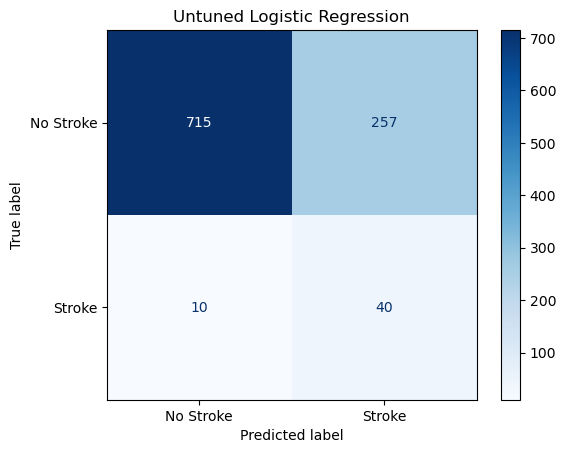

In [17]:
cm_base = confusion_matrix(y_test, y_pred_log)
ConfusionMatrixDisplay(cm_base, display_labels=['No Stroke', 'Stroke']).plot(cmap='Blues')
plt.title('Untuned Logistic Regression')
plt.show()


In [18]:
#LogisticRegression hyperparameter tunning
param_grid = {
     'C': [0.001, 0.005, 0.01, 0.05, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
grid_log = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    param_grid, scoring='recall', cv=5
)
grid_log.fit(X_train, y_train)
print("\nBest parameters:", grid_log.best_params_)



Best parameters: {'C': 0.005, 'penalty': 'l1', 'solver': 'liblinear'}


In [19]:
#retrained the model with the best parameters
tuned_log_reg = LogisticRegression(
    C=0.005, penalty='l1', solver='liblinear',
    class_weight='balanced', max_iter=1000, random_state=42
)
tuned_log_reg.fit(X_train, y_train)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.005
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [20]:
#just trying to know the effect l1 penalty
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': tuned_log_reg.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)
print(coef_df)

                           Feature  Coefficient
0                              age     1.023361
3                avg_glucose_level     0.079794
1                     hypertension     0.000000
2                    heart_disease     0.000000
4                              bmi     0.000000
5                      gender_Male     0.000000
6                 ever_married_Yes     0.000000
7           work_type_Never_worked     0.000000
8                work_type_Private     0.000000
9          work_type_Self-employed     0.000000
10              work_type_children     0.000000
11            Residence_type_Urban     0.000000
12  smoking_status_formerly smoked     0.000000
13     smoking_status_never smoked     0.000000
14           smoking_status_smokes     0.000000


In [21]:
y_pred_tuned = tuned_log_reg.predict(X_test)
y_proba_tuned = tuned_log_reg.predict_proba(X_test)[:, 1]

print("\nTuned Logistic Regression (C=0.01)")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall:", recall_score(y_test, y_pred_tuned))
print("F1-score:", f1_score(y_test, y_pred_tuned))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))


Tuned Logistic Regression (C=0.01)
Accuracy: 0.6203522504892368
Precision: 0.0995260663507109
Recall: 0.84
F1-score: 0.17796610169491525

Confusion Matrix:
 [[592 380]
 [  8  42]]


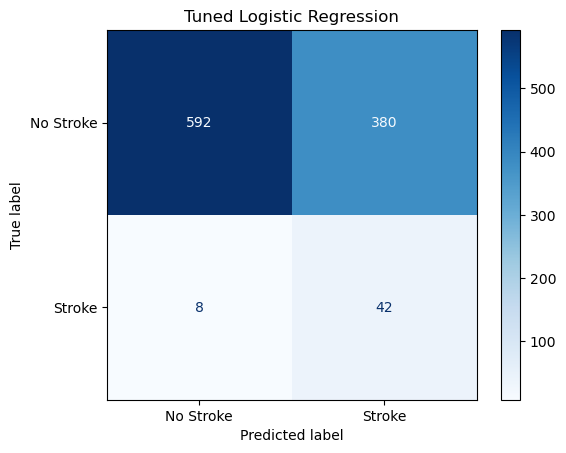

In [22]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
ConfusionMatrixDisplay(cm_tuned, display_labels=['No Stroke', 'Stroke']).plot(cmap='Blues')
plt.title('Tuned Logistic Regression')
plt.show()

In [23]:
#comparing the untuned and tuned LogisticRegression
comparison_table = pd.DataFrame({
    'Model': ['Logistic Regression (Untuned)', 'Logistic Regression (Tuned)'],
    'Parameters': ['C=1 (default), l2', 'C=0.005, l1'],
    'Accuracy': [accuracy_score(y_test, y_pred_log), accuracy_score(y_test, y_pred_tuned)],
    'Precision': [precision_score(y_test, y_pred_log), precision_score(y_test, y_pred_tuned)],
    'Recall': [recall_score(y_test, y_pred_log), recall_score(y_test, y_pred_tuned)],
    'F1-score': [f1_score(y_test, y_pred_log), f1_score(y_test, y_pred_tuned)]
})

print(comparison_table)

                           Model         Parameters  Accuracy  Precision  \
0  Logistic Regression (Untuned)  C=1 (default), l2  0.738748   0.134680   
1    Logistic Regression (Tuned)        C=0.005, l1  0.620352   0.099526   

   Recall  F1-score  
0    0.80  0.230548  
1    0.84  0.177966  


Tuning traded balance for recall: caught more real stroke cases (0.80→0.84), but at the cost of accuracy, precision, and F1. Since missed cases matter more than false alarms here, the tuned model is the better fit despite weaker overall stats.

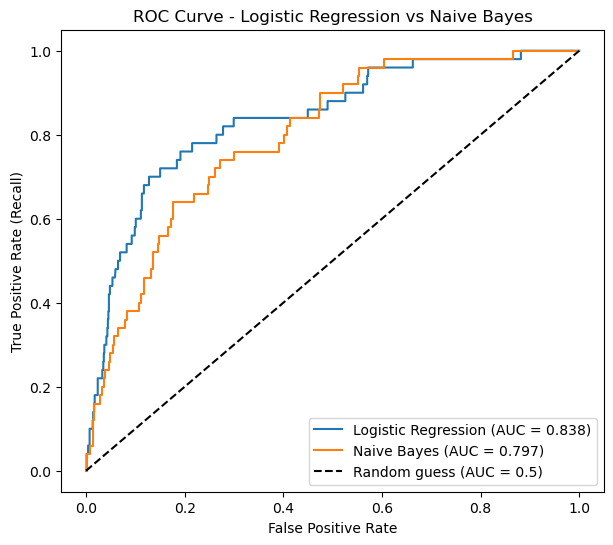

Logistic Regression AUC: 0.8383230452674896
Naive Bayes AUC: 0.796604938271605


In [63]:
from sklearn.metrics import roc_curve, roc_auc_score

# ROC curve - shows the trade-off between catching real cases
# (True Positive Rate) and false alarms (False Positive Rate)
# as the decision threshold changes, at every possible threshold
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_tuned)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_proba_nb_tuned)

auc_log = roc_auc_score(y_test, y_proba_tuned)
auc_nb = roc_auc_score(y_test, y_proba_nb_tuned)

plt.figure(figsize=(7,6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.3f})')
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random guess (AUC = 0.5)')  # baseline reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Logistic Regression vs Naive Bayes')
plt.legend()
plt.show()

print("Logistic Regression AUC:", auc_log)
print("Naive Bayes AUC:", auc_nb)

In [24]:
#the  Naïve Bayes Model
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)


,priors,None
,var_smoothing,1e-09


In [25]:
#Naive Bayes evaluation
y_pred_nb = nb.predict(X_test)
y_proba_nb = nb.predict_proba(X_test)[:, 1]  # needed later for ROC curve

print("Naive Bayes")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1-score:", f1_score(y_test, y_pred_nb))
cm_nb = confusion_matrix(y_test, y_pred_nb)
print("Confusion Matrix:")
print(cm_nb)

Naive Bayes
Accuracy: 0.36203522504892366
Precision: 0.07
Recall: 0.98
F1-score: 0.13066666666666665
Confusion Matrix:
[[321 651]
 [  1  49]]


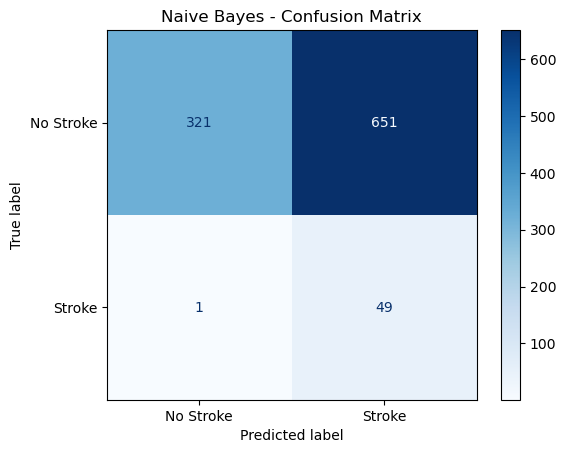

In [26]:
ConfusionMatrixDisplay(cm_nb, display_labels=['No Stroke', 'Stroke']).plot(cmap='Blues')
plt.title('Naive Bayes - Confusion Matrix')
plt.show()

In [43]:
#Naive Bayes hyperparameter tuning
import numpy as np
param_grid_nb = {'var_smoothing': np.logspace(0, -9, num=100)}

grid_nb = GridSearchCV(GaussianNB(), param_grid_nb, scoring='recall', cv=5)
grid_nb.fit(X_train, y_train)

print("Best var_smoothing:", grid_nb.best_params_)

Best var_smoothing: {'var_smoothing': np.float64(3.5111917342151273e-09)}


In [44]:
# Retrain Naive Bayes using the best var_smoothing found
best_var_smoothing = grid_nb.best_params_['var_smoothing']

tuned_nb = GaussianNB(var_smoothing=best_var_smoothing)
tuned_nb.fit(X_train, y_train)


,priors,None
,var_smoothing,np.float64(3....342151273e-09)


In [45]:
#Tuned Naive Bayes evaluation
y_pred_nb_tuned = tuned_nb.predict(X_test)
y_proba_nb_tuned = tuned_nb.predict_proba(X_test)[:, 1]  # needed later for ROC curve

print("\nTuned Naive Bayes")
print("Accuracy:", accuracy_score(y_test, y_pred_nb_tuned))
print("Precision:", precision_score(y_test, y_pred_nb_tuned))
print("Recall:", recall_score(y_test, y_pred_nb_tuned))
print("F1-score:", f1_score(y_test, y_pred_nb_tuned))


Tuned Naive Bayes
Accuracy: 0.3806262230919765
Precision: 0.07195301027900147
Recall: 0.98
F1-score: 0.13406292749658003


In [46]:
cm_nb_tuned = confusion_matrix(y_test, y_pred_nb_tuned)
print("Confusion Matrix:")
print(cm_nb_tuned)

Confusion Matrix:
[[340 632]
 [  1  49]]


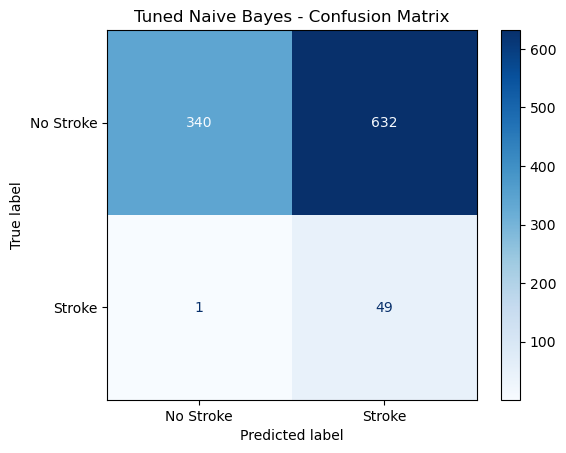

In [47]:
ConfusionMatrixDisplay(cm_nb_tuned, display_labels=['No Stroke', 'Stroke']).plot(cmap='Blues')
plt.title('Tuned Naive Bayes - Confusion Matrix')
plt.show()

In [48]:
comparison_table_nb = pd.DataFrame({
    'Model': ['Naive Bayes (Untuned)', 'Naive Bayes (Tuned)'],
    'Parameters': ['var_smoothing=1e-9 (default)', f'var_smoothing={best_var_smoothing:.2e}'],
    'Accuracy': [accuracy_score(y_test, y_pred_nb), accuracy_score(y_test, y_pred_nb_tuned)],
    'Precision': [precision_score(y_test, y_pred_nb), precision_score(y_test, y_pred_nb_tuned)],
    'Recall': [recall_score(y_test, y_pred_nb), recall_score(y_test, y_pred_nb_tuned)],
    'F1-score': [f1_score(y_test, y_pred_nb), f1_score(y_test, y_pred_nb_tuned)]
})

print(comparison_table_nb)

                   Model                    Parameters  Accuracy  Precision  \
0  Naive Bayes (Untuned)  var_smoothing=1e-9 (default)  0.362035   0.070000   
1    Naive Bayes (Tuned)        var_smoothing=3.51e-09  0.380626   0.071953   

   Recall  F1-score  
0    0.98  0.130667  
1    0.98  0.134063  


Tuning barely changed anything. Both untuned and tuned models flagged almost every patient as "at risk," catching 98% of real stroke cases — but only because they over-predicted stroke for nearly everyone, not because either model was actually accurate (36% vs 38% overall accuracy). This happened because we scored the search on recall alone, and since predicting "stroke" for everyone already gets close to perfect recall, the search had no reason to move away from that. In short, tuning var_smoothing this way couldn't fix Naïve Bayes' core problem: it has no way to account for class imbalance, so it defaults to over-predicting the rare class rather than genuinely learning to separate the two groups.

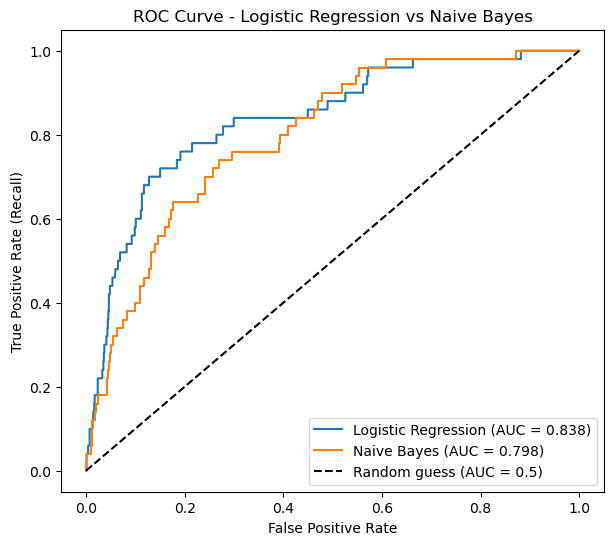

Logistic Regression AUC: 0.8383230452674896
Naive Bayes AUC: 0.7977366255144034


In [34]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_tuned)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_proba_nb_tuned)

auc_log = roc_auc_score(y_test, y_proba_tuned)
auc_nb = roc_auc_score(y_test, y_proba_nb_tuned)

plt.figure(figsize=(7,6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.3f})')
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess (AUC = 0.5)')  # baseline for comparison

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Logistic Regression vs Naive Bayes')
plt.legend()
plt.show()

print("Logistic Regression AUC:", auc_log)
print("Naive Bayes AUC:", auc_nb)

In [35]:
#Model development for none probalistic 
#SVM
from sklearn.svm import SVC

#train the svm model on the training sets
svm = SVC(class_weight='balanced', random_state=42)
svm.fit(X_train, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [37]:
y_pred_svm = svm.predict(X_test)
Svm_predicted_values = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_svm
})
print(Svm_predicted_values.head(10))


   Actual  Predicted
0       0          0
1       0          0
2       0          0
3       0          0
4       0          0
5       0          1
6       0          0
7       0          0
8       0          0
9       0          0


In [38]:
print("SVM")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1-score:", f1_score(y_test, y_pred_svm))

cm_svm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:")
print(cm_svm)

SVM
Accuracy: 0.738747553816047
Precision: 0.11929824561403508
Recall: 0.68
F1-score: 0.20298507462686566
Confusion Matrix:
[[721 251]
 [ 16  34]]


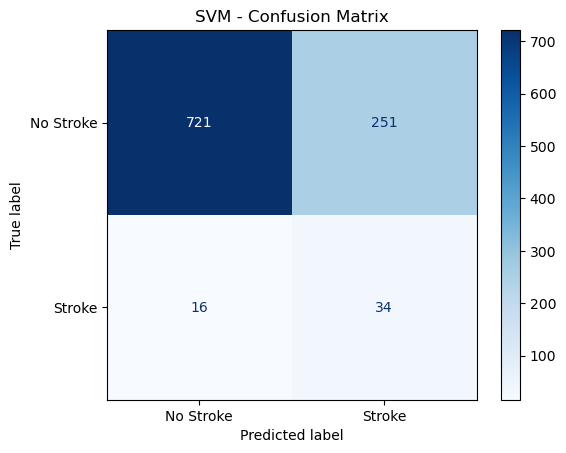

In [39]:
ConfusionMatrixDisplay(cm_svm, display_labels=['No Stroke', 'Stroke']).plot(cmap='Blues')
plt.title('SVM - Confusion Matrix')
plt.show()

In [40]:
#SVM Hyperparameter
param_grid_svm = [
    {'kernel': ['linear'], 'C': [0.1, 1, 10]},
    {'kernel': ['rbf'], 'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']},
    {'kernel': ['poly'], 'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'], 'degree': [2, 3]},
    {'kernel': ['sigmoid'], 'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']}
]

grid_svm = GridSearchCV(
    SVC(class_weight='balanced', random_state=42),
    param_grid_svm,
    scoring='recall',
    cv=5
)
grid_svm.fit(X_train, y_train)

print("Best parameters:", grid_svm.best_params_)


Best parameters: {'C': 0.1, 'gamma': 'auto', 'kernel': 'sigmoid'}


In [41]:
# retrain explicitly with the best parameters found
svm_sigmoid = SVC(C=0.1, gamma='auto', kernel='sigmoid', class_weight='balanced', random_state=42)
svm_sigmoid.fit(X_train, y_train)

,C,0.1
,kernel,'sigmoid'
,degree,3
,gamma,'auto'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [42]:
#predicting svm model
y_pred_sigmoid = svm_sigmoid.predict(X_test)
print("\nSigmoid - Accuracy:", accuracy_score(y_test, y_pred_sigmoid))
print("Sigmoid - Precision:", precision_score(y_test, y_pred_sigmoid))
print("Sigmoid - Recall:", recall_score(y_test, y_pred_sigmoid))
print("Sigmoid - F1:", f1_score(y_test, y_pred_sigmoid))

cm_svm_sigmoid = confusion_matrix(y_test, y_pred_sigmoid)
print("Confusion Matrix sigmoid:")
print(cm_svm_sigmoid)


Sigmoid - Accuracy: 0.6927592954990215
Sigmoid - Precision: 0.1206896551724138
Sigmoid - Recall: 0.84
Sigmoid - F1: 0.21105527638190955
Confusion Matrix sigmoid:
[[666 306]
 [  8  42]]


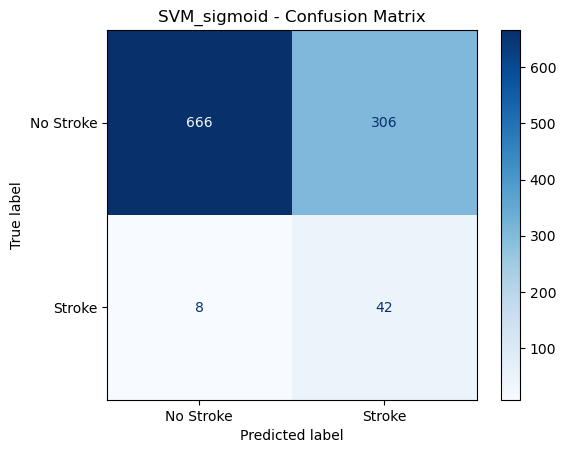

In [49]:
ConfusionMatrixDisplay(cm_svm_sigmoid, display_labels=['No Stroke', 'Stroke']).plot(cmap='Blues')
plt.title('SVM_sigmoid - Confusion Matrix')
plt.show()

In [ ]:
comparison_table_svm = pd.DataFrame({
    'Model': ['SVM (Untuned)', 'SVM (Tuned)'],
    'Parameters': ['C=1 (default), rbf', 'C=0.1, gamma=auto, sigmoid'],
    'Accuracy': [accuracy_score(y_test, y_pred_svm), accuracy_score(y_test, y_pred_sigmoid)],
    'Precision': [precision_score(y_test, y_pred_svm), precision_score(y_test, y_pred_sigmoid)],
    'Recall': [recall_score(y_test, y_pred_svm), recall_score(y_test, y_pred_sigmoid)],
    'F1-score': [f1_score(y_test, y_pred_svm), f1_score(y_test, y_pred_sigmoid)]
})

print(comparison_table_svm)

Tuning improved SVM cleanly: recall rose from 0.68 to 0.84 (8 more real stroke cases caught), while precision and F1 also improved slightly. Accuracy dropped a bit, which is the expected trade-off of flagging more patients as at-risk.

In [50]:
#None probalistic model KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [51]:
y_pred_knn = knn.predict(X_test)

predicted_values = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_knn
})
print(predicted_values.head(10))

   Actual  Predicted
0       0          0
1       0          0
2       0          0
3       0          0
4       0          0
5       0          0
6       0          0
7       0          0
8       0          0
9       0          0


In [52]:
print("KNN")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1-score:", f1_score(y_test, y_pred_knn))

cm_knn = confusion_matrix(y_test, y_pred_knn)
print("Confusion Matrix KNN:")
print(cm_knn)

KNN
Accuracy: 0.9471624266144814
Precision: 0.0
Recall: 0.0
F1-score: 0.0
Confusion Matrix KNN:
[[968   4]
 [ 50   0]]


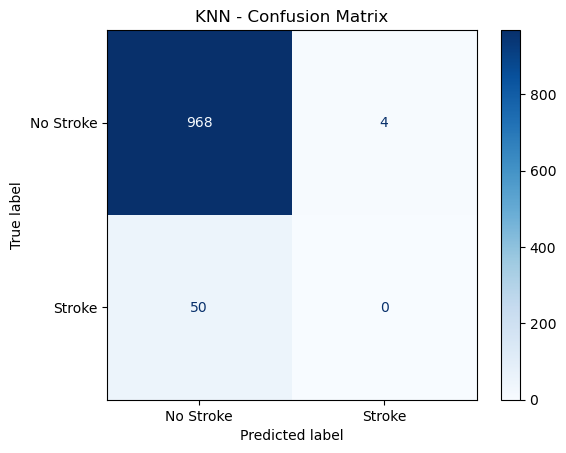

In [53]:
ConfusionMatrixDisplay(cm_knn, display_labels=['No Stroke', 'Stroke']).plot(cmap='Blues')
plt.title('KNN - Confusion Matrix')
plt.show()

In [54]:

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    scoring='recall',
    cv=5
)
grid_knn.fit(X_train, y_train)

print("Best parameters:", grid_knn.best_params_)

Best parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}


In [57]:
best_params_knn = grid_knn.best_params_
tuned_knn = KNeighborsClassifier(**best_params_knn)
tuned_knn.fit(X_train, y_train)

,n_neighbors,3
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'manhattan'
,metric_params,None
,n_jobs,None


In [58]:
y_pred_knn_tuned = tuned_knn.predict(X_test)

print("\nTuned KNN")
print("Accuracy:", accuracy_score(y_test, y_pred_knn_tuned))
print("Precision:", precision_score(y_test, y_pred_knn_tuned))
print("Recall:", recall_score(y_test, y_pred_knn_tuned))
print("F1-score:", f1_score(y_test, y_pred_knn_tuned))

cm_knn_tuned = confusion_matrix(y_test, y_pred_knn_tuned)
print("Confusion Matrix KNN:")
print(cm_knn_tuned)


Tuned KNN
Accuracy: 0.9432485322896281
Precision: 0.16666666666666666
Recall: 0.04
F1-score: 0.06451612903225806
Confusion Matrix KNN:
[[962  10]
 [ 48   2]]


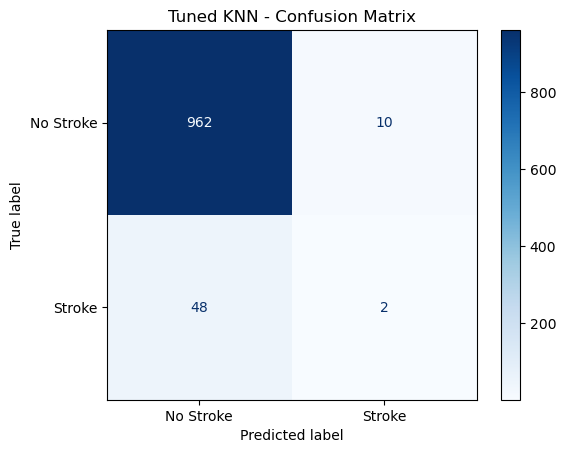

In [59]:
ConfusionMatrixDisplay(cm_knn_tuned, display_labels=['No Stroke', 'Stroke']).plot(cmap='Blues')
plt.title('Tuned KNN - Confusion Matrix')
plt.show()

In [60]:
comparison_table_knn = pd.DataFrame({
    'Model': ['KNN (Untuned)', 'KNN (Tuned)'],
    'Parameters': ['k=5 (default), uniform, minkowski', str(best_params_knn)],
    'Accuracy': [accuracy_score(y_test, y_pred_knn), accuracy_score(y_test, y_pred_knn_tuned)],
    'Precision': [precision_score(y_test, y_pred_knn), precision_score(y_test, y_pred_knn_tuned)],
    'Recall': [recall_score(y_test, y_pred_knn), recall_score(y_test, y_pred_knn_tuned)],
    'F1-score': [f1_score(y_test, y_pred_knn), f1_score(y_test, y_pred_knn_tuned)]
})
print(comparison_table_knn)

           Model                                         Parameters  Accuracy  \
0  KNN (Untuned)                  k=5 (default), uniform, minkowski  0.947162   
1    KNN (Tuned)  {'metric': 'manhattan', 'n_neighbors': 3, 'wei...  0.943249   

   Precision  Recall  F1-score  
0   0.000000    0.00  0.000000  
1   0.166667    0.04  0.064516  


Tuning barely improved KNN, recall only rose from 0 to 0.04 (2 of 50 real cases caught). Unlike Logistic Regression and SVM, KNN has no way to account for class imbalance, so no combination of k/weights/distance metric could meaningfully fix its bias toward the majority class.

In [61]:
final_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'SVM', 'KNN'],
    'Type': ['Probabilistic', 'Probabilistic', 'Non-Probabilistic', 'Non-Probabilistic'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_tuned),
        accuracy_score(y_test, y_pred_nb_tuned),
        accuracy_score(y_test, y_pred_sigmoid),
        accuracy_score(y_test, y_pred_knn_tuned)
    ],
    'Precision': [
        precision_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_nb_tuned),
        precision_score(y_test, y_pred_sigmoid),
        precision_score(y_test, y_pred_knn_tuned)
    ],
    'Recall': [
        recall_score(y_test, y_pred_tuned),
        recall_score(y_test, y_pred_nb_tuned),
        recall_score(y_test, y_pred_sigmoid),
        recall_score(y_test, y_pred_knn_tuned)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_nb_tuned),
        f1_score(y_test, y_pred_sigmoid),
        f1_score(y_test, y_pred_knn_tuned)
    ]
})

print(final_comparison)

                 Model               Type  Accuracy  Precision  Recall  \
0  Logistic Regression      Probabilistic  0.620352   0.099526    0.84   
1          Naive Bayes      Probabilistic  0.380626   0.071953    0.98   
2                  SVM  Non-Probabilistic  0.692759   0.120690    0.84   
3                  KNN  Non-Probabilistic  0.943249   0.166667    0.04   

   F1-score  
0  0.177966  
1  0.134063  
2  0.211055  
3  0.064516  
